# EDA — VQAv2 Dataset

Notebook này thực hiện **Exploratory Data Analysis (EDA)** toàn diện trên tập dữ liệu VQAv2, bao gồm:

| # | Nội dung |
|---|----------|
| 1 | **Setup** — Mount Google Drive, cấu hình đường dẫn |
| 2 | **Tổng quan** — Số lượng câu hỏi, annotation, ảnh |
| 3 | **Phân phối câu trả lời** — answer type, top-40 answers, mức độ đồng thuận |
| 4 | **Phân phối câu hỏi** — question type, độ dài câu, word cloud |
| 5 | **So sánh Train vs Val** — phân phối chéo giữa hai split |
| 6 | **Thống kê ảnh** — số ảnh, số câu hỏi/ảnh |
| 7 | **Mẫu dữ liệu** — hiển thị ảnh + câu hỏi + câu trả lời |

## 0  Setup: Mount Drive & Cấu hình đường dẫn

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
from pathlib import Path

DRIVE_ROOT  = Path('/content/drive/MyDrive/kì 2 năm 4/deep learning/blip2_project/data')
VQA_DIR     = DRIVE_ROOT / 'vqav2'          # chứa các file JSON
IMG_TRAIN   = DRIVE_ROOT / '/coco/train2014'      # ảnh train
IMG_VAL     = DRIVE_ROOT / '/coco/val2014'        # ảnh val
FEAT_DIR    = DRIVE_ROOT / 'cache'       # HDF5 cache

TRAIN_Q_FILE  = VQA_DIR / 'v2_OpenEnded_mscoco_train2014_questions.json'
TRAIN_A_FILE  = VQA_DIR / 'v2_mscoco_train2014_annotations.json'
VAL_Q_FILE    = VQA_DIR / 'v2_OpenEnded_mscoco_val2014_questions.json'
VAL_A_FILE    = VQA_DIR / 'v2_mscoco_val2014_annotations.json'
ANSWER_LIST   = '/content/drive/MyDrive/kì 2 năm 4/deep learning/blip2_project/data/ans2idx.json'   # vocab 3129 answers

for p in [TRAIN_Q_FILE, TRAIN_A_FILE, VAL_Q_FILE, VAL_A_FILE]:
    status = 'OK' if p.exists() else 'KHÔNG TÌM THẤY'
    print(f'{status}  {p}')

OK  /content/drive/MyDrive/kì 2 năm 4/deep learning/blip2_project/data/vqav2/v2_OpenEnded_mscoco_train2014_questions.json
OK  /content/drive/MyDrive/kì 2 năm 4/deep learning/blip2_project/data/vqav2/v2_mscoco_train2014_annotations.json
OK  /content/drive/MyDrive/kì 2 năm 4/deep learning/blip2_project/data/vqav2/v2_OpenEnded_mscoco_val2014_questions.json
OK  /content/drive/MyDrive/kì 2 năm 4/deep learning/blip2_project/data/vqav2/v2_mscoco_val2014_annotations.json


## 1  Cài đặt thư viện bổ sung

In [5]:
!pip install wordcloud --quiet

In [6]:
import json
import re
import unicodedata
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
from wordcloud import WordCloud
from IPython.display import display

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

SAVE_DIR = Path('eda_figures')
SAVE_DIR.mkdir(exist_ok=True)

print('Thư viện import thành công.')

Thư viện import thành công.


## 2  Load dữ liệu

In [7]:
def load_split(q_file: Path, a_file: Path):
    """Load questions + annotations, trả về list và dict tra cứu nhanh."""
    print(f'  Loading {q_file.name} …', end=' ')
    with open(q_file) as f:
        q_raw = json.load(f)
    print(f'{len(q_raw["questions"]):,} questions')

    print(f'  Loading {a_file.name} …', end=' ')
    with open(a_file) as f:
        a_raw = json.load(f)
    print(f'{len(a_raw["annotations"]):,} annotations')

    # dict: question_id → annotation
    ann_lookup = {a['question_id']: a for a in a_raw['annotations']}
    return q_raw['questions'], ann_lookup


print('── Train ──')
train_qs, train_anns = load_split(TRAIN_Q_FILE, TRAIN_A_FILE)

print('── Val ──')
val_qs, val_anns = load_split(VAL_Q_FILE, VAL_A_FILE)

── Train ──
  Loading v2_OpenEnded_mscoco_train2014_questions.json … 443,757 questions
  Loading v2_mscoco_train2014_annotations.json … 443,757 annotations
── Val ──
  Loading v2_OpenEnded_mscoco_val2014_questions.json … 214,354 questions
  Loading v2_mscoco_val2014_annotations.json … 214,354 annotations


## 3  Tổng quan Dataset

In [8]:
train_img_ids = {q['image_id'] for q in train_qs}
val_img_ids   = {q['image_id'] for q in val_qs}

summary = pd.DataFrame([
    {'Split': 'Train', 'Câu hỏi': len(train_qs), 'Ảnh': len(train_img_ids),
     'Q/P': len(train_qs) / len(train_img_ids)},
    {'Split': 'Val',   'Câu hỏi': len(val_qs),   'Ảnh': len(val_img_ids),
     'Q/P': len(val_qs) / len(val_img_ids)},
    {'Split': 'Total', 'Câu hỏi': len(train_qs) + len(val_qs),
     'Ảnh': len(train_img_ids | val_img_ids),
     'Q/P': (len(train_qs) + len(val_qs)) / len(train_img_ids | val_img_ids)},
])
summary['Câu hỏi'] = summary['Câu hỏi'].map('{:,}'.format)
summary['Ảnh'] = summary['Ảnh'].map('{:,}'.format)
summary['Q/P'] = summary['Q/P'].map('{:.2f}'.format)
display(summary.set_index('Split'))

# Tải answer vocab
if isinstance(ANSWER_LIST, str):
    ANSWER_LIST = Path(ANSWER_LIST)

if ANSWER_LIST.exists():
    with open(ANSWER_LIST) as f:
        answer_vocab = json.load(f)
    answer_vocab_set = set(answer_vocab)
    print(f'Answer vocab size: {len(answer_vocab):,}  |  Answer type: yes/no, number, other')
else:
    answer_vocab = []
    answer_vocab_set = set()
    print('\n answer_list.json không tìm thấy')

,Câu hỏi,Ảnh,Q/P
Split,,,
Train,"443,757","82,783",5.36
Val,"214,354","40,504",5.29
Total,"658,111","123,287",5.34


Answer vocab size: 3,129  |  Answer type: yes/no, number, other


## 4  Phân phối câu trả lời

### 4.1  Answer type (yes/no · number · other)

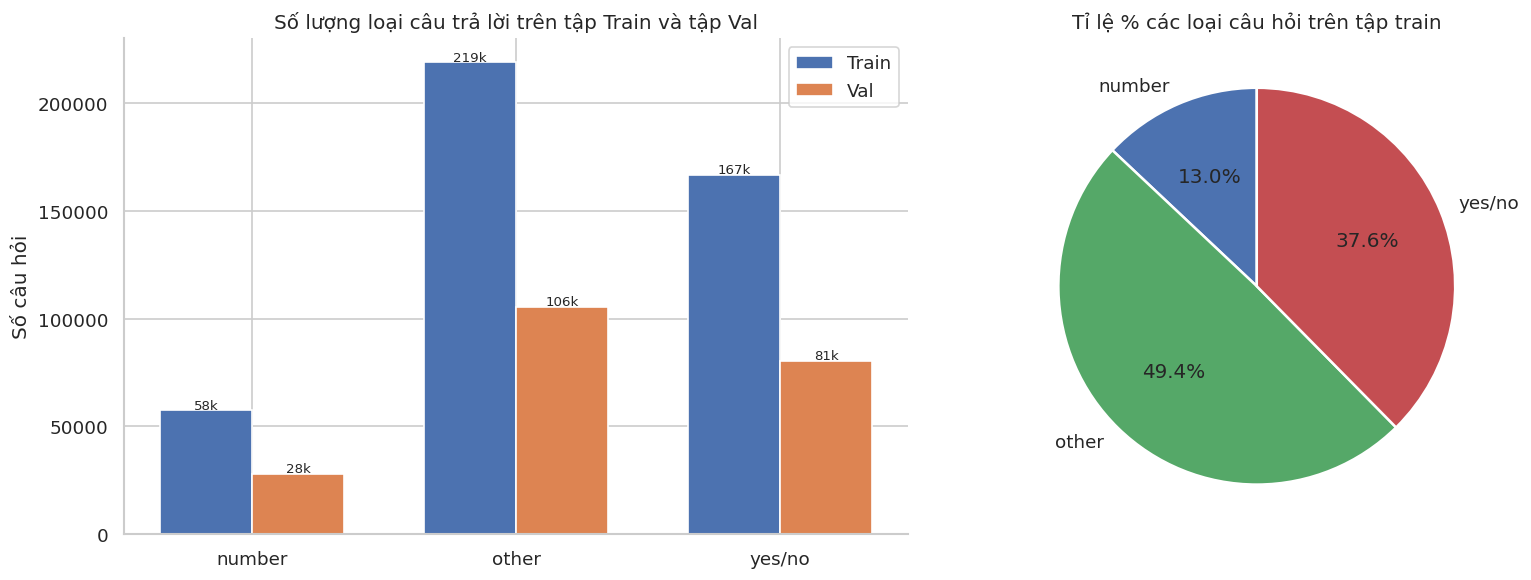

Train: {'other': 219269, 'yes/no': 166882, 'number': 57606}
Val:   {'other': 105679, 'yes/no': 80541, 'number': 28134}


In [26]:
def get_answer_type_counts(anns: dict):
    return Counter(a['answer_type'] for a in anns.values())

train_at = get_answer_type_counts(train_anns)
val_at   = get_answer_type_counts(val_anns)

labels = sorted(set(train_at) | set(val_at))
x = np.arange(len(labels))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ cột so sánh
axes[0].bar(x - w/2, [train_at[l] for l in labels], w, label='Train', color='#4C72B0')
axes[0].bar(x + w/2, [val_at[l]   for l in labels], w, label='Val',   color='#DD8452')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_title('Số lượng loại câu trả lời trên tập Train và tập Val')
axes[0].set_ylabel('Số câu hỏi')
axes[0].legend()
# thêm nhãn số
for xi, (tv, vv) in enumerate(zip([train_at[l] for l in labels], [val_at[l] for l in labels])):
    axes[0].text(xi - w/2, tv + 500, f'{tv/1000:.0f}k', ha='center', fontsize=8)
    axes[0].text(xi + w/2, vv + 500, f'{vv/1000:.0f}k', ha='center', fontsize=8)

# Pie chart tỉ lệ train
colors = ['#4C72B0', '#55A868', '#C44E52']
axes[1].pie(
    [train_at[l] for l in labels],
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
)
axes[1].set_title('Tỉ lệ % các loại câu hỏi trên tập train')

plt.tight_layout()
# plt.savefig(SAVE_DIR / '01_answer_type_distribution.png', bbox_inches='tight')
plt.show()

print('Train:', dict(train_at))
print('Val:  ', dict(val_at))

### 4.2  Top-40 câu trả lời phổ biến nhất (Train)

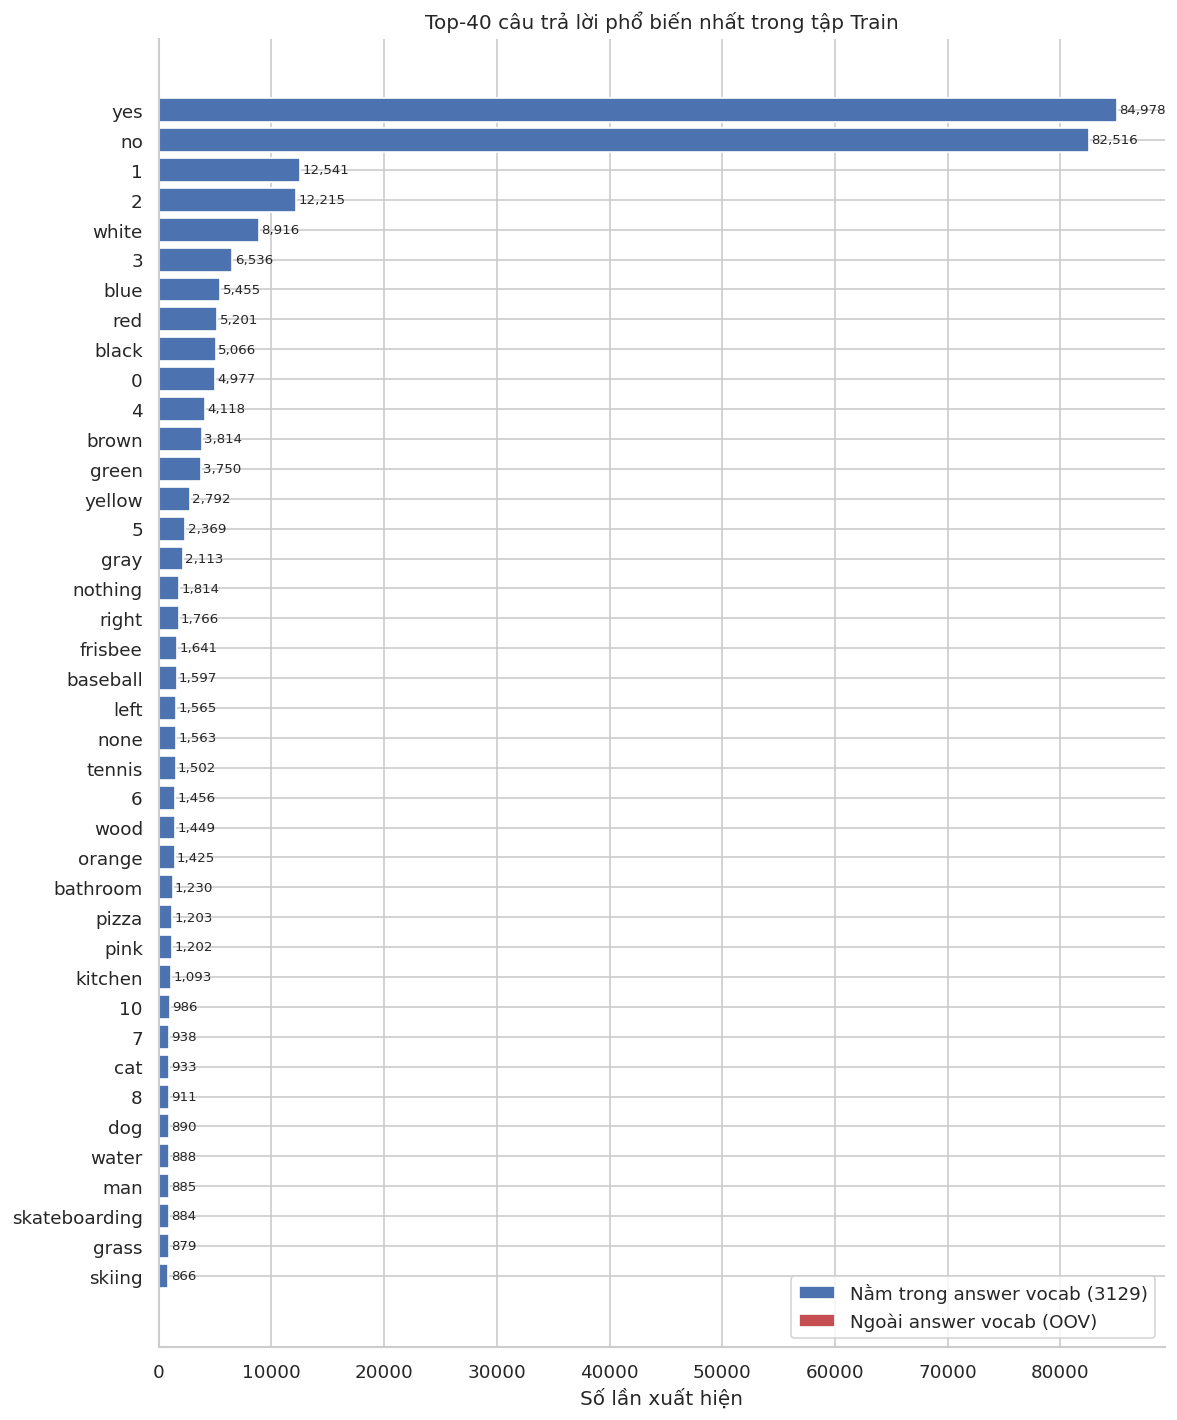

In [10]:
def normalize_answer(s: str) -> str:
    """Chuẩn hoá giống VQAv2 official eval."""
    s = s.lower().strip()
    # loại dấu câu ngoại trừ apostrophe
    s = re.sub(r"(?!')[\W+]", ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s


TOP_N = 40
train_ans_counter = Counter(
    normalize_answer(a['multiple_choice_answer'])
    for a in train_anns.values()
)
top_answers = train_ans_counter.most_common(TOP_N)
labels_top, counts_top = zip(*top_answers)

fig, ax = plt.subplots(figsize=(10, 12))
colors_bar = ['#4C72B0' if l in answer_vocab_set else '#C44E52' for l in labels_top]
bars = ax.barh(list(reversed(labels_top)), list(reversed(counts_top)), color=list(reversed(colors_bar)))

# chú thích số
for bar, cnt in zip(bars, reversed(counts_top)):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height() / 2,
            f'{cnt:,}', va='center', fontsize=8)

ax.set_xlabel('Số lần xuất hiện')
ax.set_title(f'Top-{TOP_N} câu trả lời phổ biến nhất trong tập Train')

# legend để giải thích màu
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4C72B0', label='Nằm trong answer vocab (3129)'),
    Patch(facecolor='#C44E52', label='Ngoài answer vocab (OOV)'),
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
# plt.savefig(SAVE_DIR / '02_top40_answers.png', bbox_inches='tight')
plt.show()

### 4.3  Mức độ đồng thuận giữa các annotator

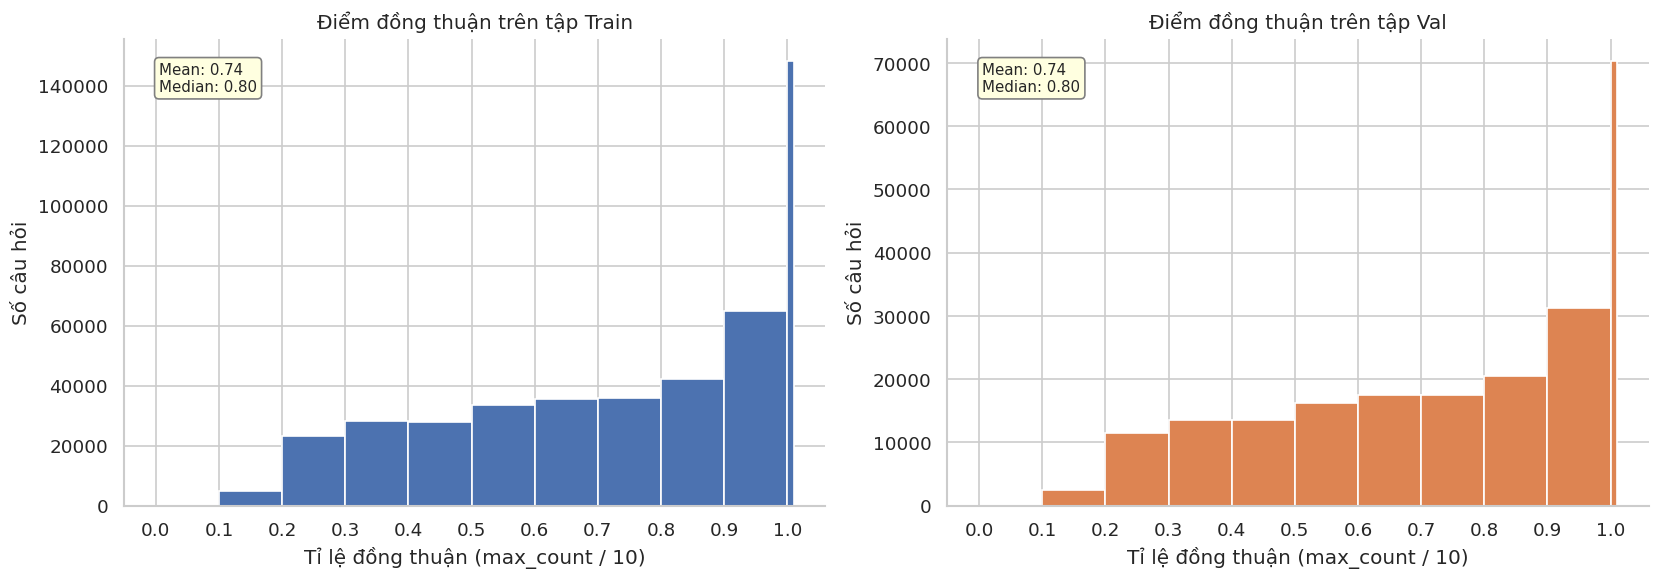

Train — Đồng thuận 100% (10/10): 148,202 (33.4%)
Val   — Đồng thuận 100% (10/10): 70,318   (32.8%)


In [11]:
def agreement_score(ann: dict) -> float:
    """Tỉ lệ đồng thuận là một chỉ số đo lường
    mức độ thống nhất giữa các người gắn nhãn (annotators) cho cùng một câu hỏi.
    Cách thu thập:
    (1) Mỗi câu hỏi trong VQAv2 được đưa cho 10 người khác nhau trả lời.
    (2) Đếm xem câu trả lời nào xuất hiện nhiều nhất trong số 10 câu trả lời đó.

    Công thức: Số lần xuất hiện nhiều nhất / 10.
    Ví dụ: Nếu 7/10 người đồng ý, điểm là 0.7. Nếu cả 10 người trả lời giống hệt nhau, điểm là 1.0 (đồng thuận 100%).
    Ý nghĩa: Điểm càng cao thì câu trả lời càng khách quan và rõ ràng.
    Điểm thấp (ví dụ 0.3) cho thấy câu hỏi đó có thể gây tranh cãi, khó hiểu hoặc hình ảnh không rõ ràng khiến mỗi người trả lời một kiểu.
    """
    # Lấy danh sách 10 câu trả lời từ các annotators
    answers = [normalize_answer(a['answer']) for a in ann['answers']]
    # Tìm số lần xuất hiện của câu trả lời phổ biến nhất
    most_common_count = Counter(answers).most_common(1)[0][1]
    # Chia cho tổng số annotators (10)
    return most_common_count / 10.0

train_agree = [agreement_score(a) for a in train_anns.values()]
val_agree   = [agreement_score(a) for a in val_anns.values()]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bins = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.01]
for ax, data, title, color in [
    (axes[0], train_agree, 'Train', '#4C72B0'),
    (axes[1], val_agree,   'Val',   '#DD8452'),
]:
    ax.hist(data, bins=bins, color=color, edgecolor='white')
    ax.set_title(f'Điểm đồng thuận trên tập {title}')
    ax.set_xlabel('Tỉ lệ đồng thuận (max_count / 10)')
    ax.set_ylabel('Số câu hỏi')
    ax.set_xticks([0.1 * i for i in range(11)])
    ax.text(0.05, 0.95, f'Mean: {np.mean(data):.2f}\nMedian: {np.median(data):.2f}',
            transform=ax.transAxes, va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', ec='gray'))

plt.tight_layout()
# plt.savefig(SAVE_DIR / '03_agreement_distribution.png', bbox_inches='tight')
plt.show()

full_agree_train = sum(1 for s in train_agree if s == 1.0)
print(f'Train — Đồng thuận 100% (10/10): {full_agree_train:,} ({100*full_agree_train/len(train_agree):.1f}%)')
full_agree_val = sum(1 for s in val_agree if s == 1.0)
print(f'Val   — Đồng thuận 100% (10/10): {full_agree_val:,}   ({100*full_agree_val/len(val_agree):.1f}%)')

### 4.4  Coverage của answer vocab (3129 answers)

Train — Coverage: 411,179 / 443,757 = 92.66%
Val   — Coverage: 197,604   / 214,354   = 92.19%


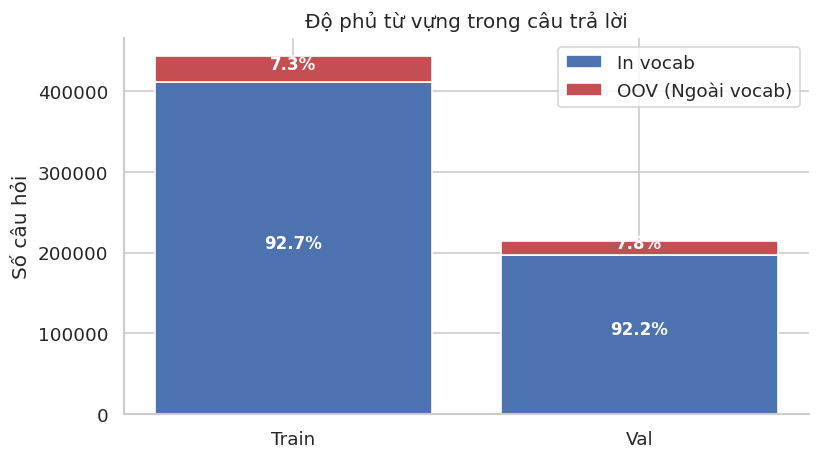

In [12]:
if answer_vocab:
    def compute_coverage(anns: dict) -> dict:
      """
      Tính tỉ lệ phần trăm các câu hỏi mà câu trả lời của chúng
      nằm trong danh sách từ vựng cho trước (answer vocab)
      """
      total = 0
      in_vocab = 0
      for a in anns.values():
            ans = normalize_answer(a['multiple_choice_answer'])
            total += 1
            if ans in answer_vocab_set:
                in_vocab += 1
      return {'total': total, 'in_vocab': in_vocab, 'coverage': in_vocab / total * 100}

    cov_train = compute_coverage(train_anns)
    cov_val   = compute_coverage(val_anns)

    print(f'Train — Coverage: {cov_train["in_vocab"]:,} / {cov_train["total"]:,} = {cov_train["coverage"]:.2f}%')
    print(f'Val   — Coverage: {cov_val["in_vocab"]:,}   / {cov_val["total"]:,}   = {cov_val["coverage"]:.2f}%')

    # Biểu đồ stacked bar
    fig, ax = plt.subplots(figsize=(7, 4))
    splits = ['Train', 'Val']
    in_v  = [cov_train['in_vocab'], cov_val['in_vocab']]
    oov   = [cov_train['total'] - cov_train['in_vocab'],
              cov_val['total']   - cov_val['in_vocab']]
    ax.bar(splits, in_v,  label='In vocab', color='#4C72B0')
    ax.bar(splits, oov,   label='OOV (Ngoài vocab)', color='#C44E52', bottom=in_v)
    ax.set_ylabel('Số câu hỏi')
    ax.set_title('Độ phủ từ vựng trong câu trả lời')
    ax.legend()
    for xi, (iv, ov, tot) in enumerate(zip(in_v, oov, [cov_train['total'], cov_val['total']])):
        ax.text(xi, iv / 2, f'{iv/tot*100:.1f}%', ha='center', color='white', fontsize=10, fontweight='bold')
        if ov > 0:
            ax.text(xi, iv + ov / 2, f'{ov/tot*100:.1f}%', ha='center', color='white', fontsize=10, fontweight='bold')
    plt.tight_layout()
    # plt.savefig(SAVE_DIR / '04_answer_vocab_coverage.png', bbox_inches='tight')
    plt.show()
else:
    print('Bỏ qua: answer_list.json chưa load.')

## 5  Phân phối câu hỏi

### 5.1  Question type (từ đầu tiên)

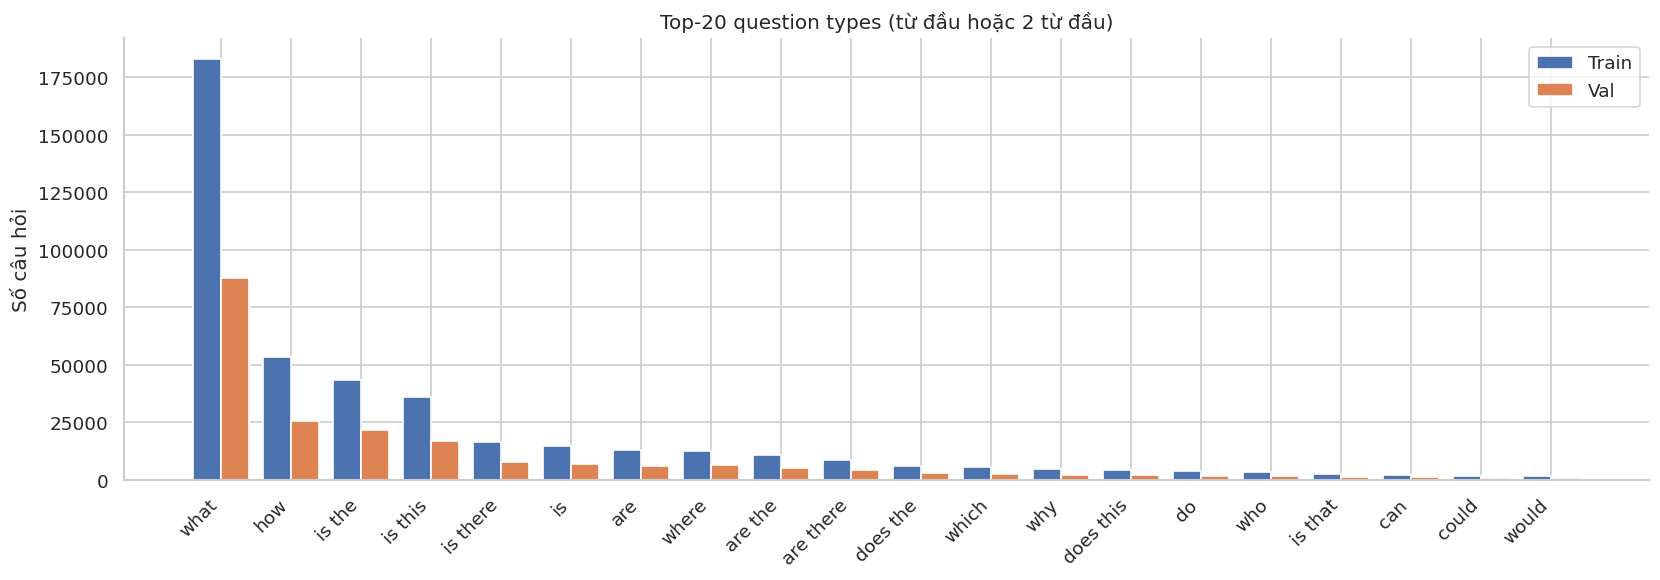

Train top-5: [('what', 182840), ('how', 53426), ('is the', 43531), ('is this', 36205), ('is there', 16495)]
Val   top-5: [('what', 87868), ('how', 25794), ('is the', 21562), ('is this', 16957), ('is there', 7799)]


In [13]:
def get_question_type(q: str) -> str:
    """Trích loại câu hỏi từ từ đầu tiên (hoặc 2 từ đầu cho is there, are there …)."""
    tokens = q.lower().split()
    if len(tokens) >= 2 and tokens[0] in ('is', 'are', 'was', 'were', 'has', 'have', 'can', 'do', 'does', 'did'):
        return f'{tokens[0]} {tokens[1]}' if tokens[1] in ('there', 'the', 'this', 'that', 'a', 'an', 'any') else tokens[0]
    return tokens[0] if tokens else 'unknown'


TOP_QT = 20
train_qt = Counter(get_question_type(q['question']) for q in train_qs)
val_qt   = Counter(get_question_type(q['question']) for q in val_qs)

top_qt_labels = [l for l, _ in train_qt.most_common(TOP_QT)]
x = np.arange(len(top_qt_labels))
w = 0.4

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - w/2, [train_qt[l] for l in top_qt_labels], w, label='Train', color='#4C72B0')
ax.bar(x + w/2, [val_qt[l]   for l in top_qt_labels], w, label='Val',   color='#DD8452')
ax.set_xticks(x)
ax.set_xticklabels(top_qt_labels, rotation=45, ha='right')
ax.set_ylabel('Số câu hỏi')
ax.set_title(f'Top-{TOP_QT} question types (từ đầu hoặc 2 từ đầu)')
ax.legend()

plt.tight_layout()
# plt.savefig(SAVE_DIR / '05_question_type_distribution.png', bbox_inches='tight')
plt.show()

print('Train top-5:', train_qt.most_common(5))
print('Val   top-5:', val_qt.most_common(5))

### 5.2  Phân phối độ dài câu hỏi (số từ)

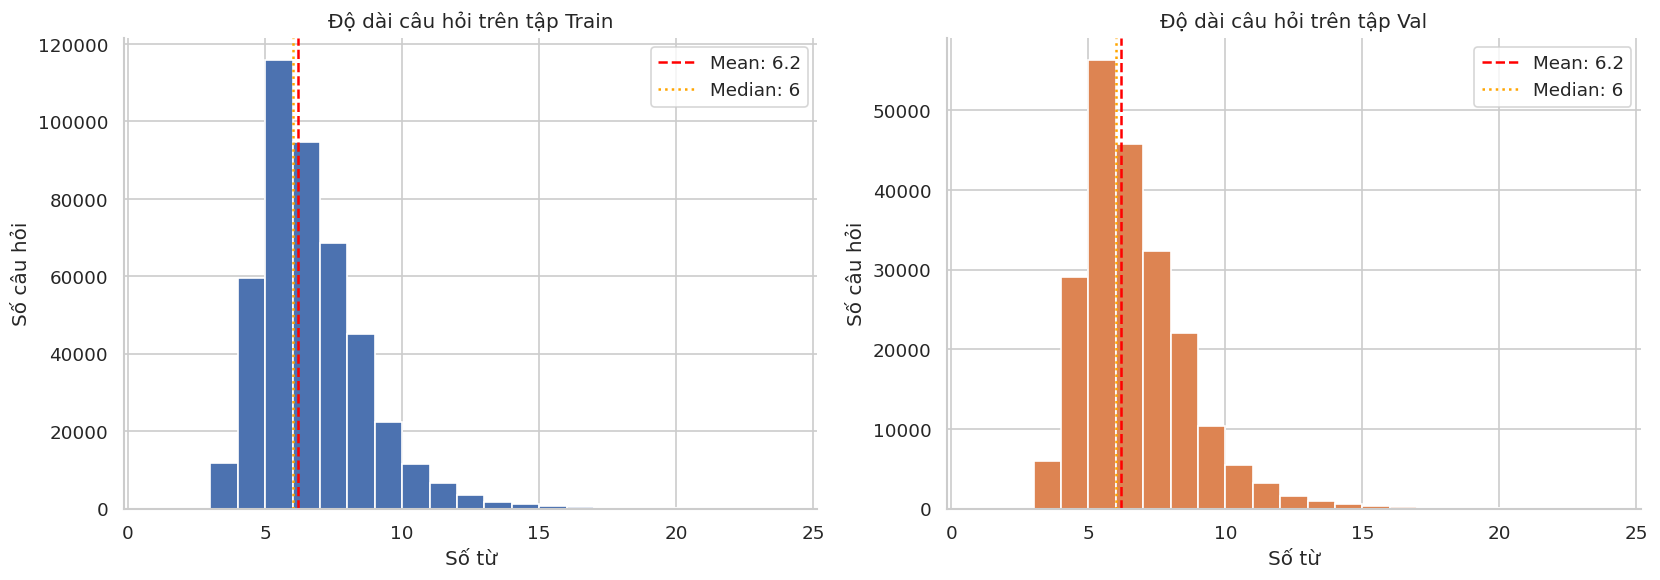

Train — Mean: 6.2 | Median: 6 | Max: 22 | Std: 1.9
Val — Mean: 6.2 | Median: 6 | Max: 23 | Std: 1.9


In [20]:
train_q_lengths = [len(q['question'].split()) for q in train_qs]
val_q_lengths   = [len(q['question'].split()) for q in val_qs]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, title, color in [
    (axes[0], train_q_lengths, 'Train', '#4C72B0'),
    (axes[1], val_q_lengths,   'Val',   '#DD8452'),
]:
    ax.hist(data, bins=range(1, 25), color=color, edgecolor='white')
    ax.axvline(np.mean(data),   color='red',    linestyle='--', linewidth=1.5, label=f'Mean: {np.mean(data):.1f}')
    ax.axvline(np.median(data), color='orange', linestyle=':',  linewidth=1.5, label=f'Median: {np.median(data):.0f}')
    ax.set_xlabel('Số từ')
    ax.set_ylabel('Số câu hỏi')
    ax.set_title(f'Độ dài câu hỏi trên tập {title}')
    ax.legend()

plt.tight_layout()
# plt.savefig(SAVE_DIR / '06_question_length.png', bbox_inches='tight')
plt.show()

for split, data in [('Train', train_q_lengths), ('Val', val_q_lengths)]:
    print(f'{split} — Mean: {np.mean(data):.1f} | Median: {np.median(data):.0f} | Max: {max(data)} | Std: {np.std(data):.1f}')

### 5.3  Word Cloud câu hỏi (Train)

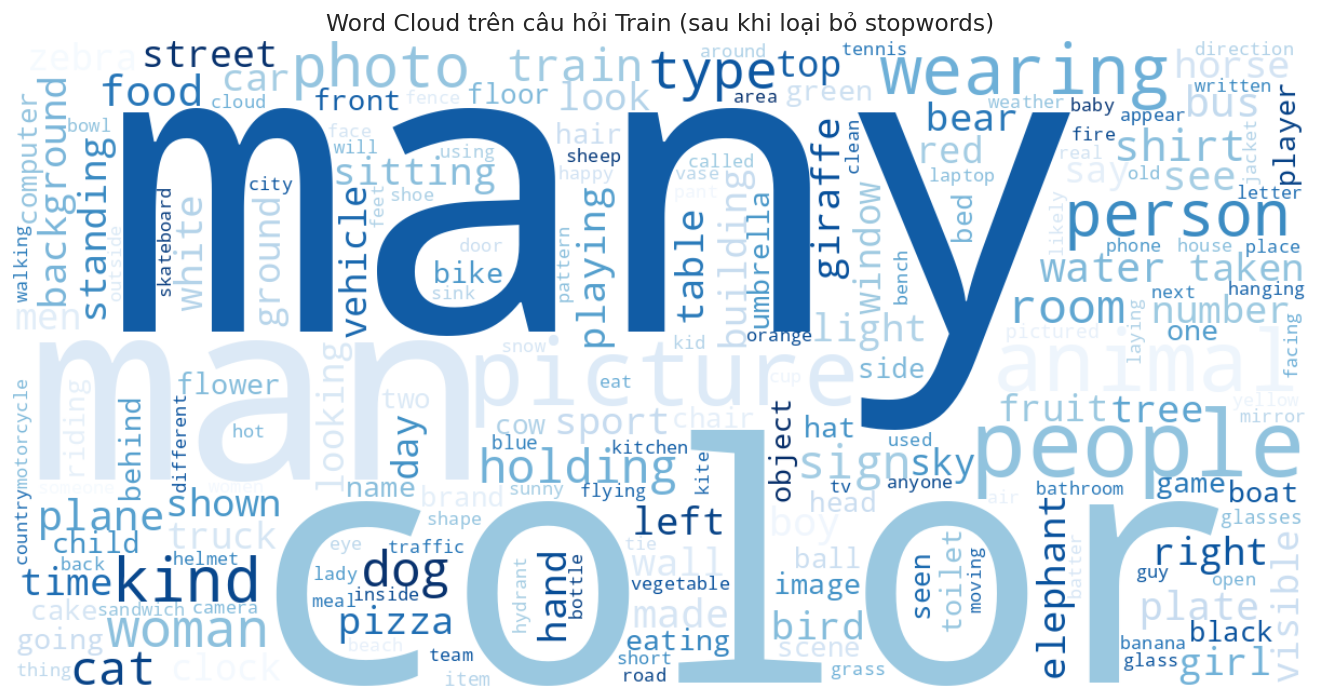

In [21]:
STOPWORDS = {
    'the', 'a', 'an', 'is', 'are', 'was', 'were', 'in', 'on', 'of',
    'to', 'and', 'this', 'that', 'it', 'be', 'do', 'does', 'has',
    'have', 'for', 'at', 'by', 'with', 'what', 'what\'s',
}

all_words_train = ' '.join(
    ' '.join(w for w in q['question'].lower().split() if w not in STOPWORDS)
    for q in train_qs
)

wc = WordCloud(
    width=1200, height=600,
    background_color='white',
    max_words=200,
    colormap='Blues',
    collocations=False,
)
wc.generate(all_words_train)

fig, ax = plt.subplots(figsize=(14, 6))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Word Cloud trên câu hỏi Train (sau khi loại bỏ stopwords)', fontsize=14)
plt.tight_layout()
# plt.savefig(SAVE_DIR / '07_question_wordcloud.png', bbox_inches='tight')
plt.show()

## 6  Xem mẫu dữ liệu (ảnh + QA)

In [28]:
import random

N_SAMPLES  = 8
COLS       = 4
ROWS       = N_SAMPLES // COLS

random.seed(42)
sample_qs = random.sample(val_qs, N_SAMPLES)

has_images = IMG_VAL.exists()

if has_images:
    fig, axes = plt.subplots(ROWS, COLS, figsize=(COLS * 5, ROWS * 5))
    axes = axes.flatten()

for idx, q in enumerate(sample_qs):
    qid    = q['question_id']
    ann    = val_anns.get(qid, {})
    answer = ann.get('multiple_choice_answer', '?')
    q_type = ann.get('question_type', '')
    a_type = ann.get('answer_type', '')
    all_answers = [a['answer'] for a in ann.get('answers', [])]
    agree_str = ' | '.join(f"{a}: {all_answers.count(a)}x" for a in sorted(set(all_answers), key=all_answers.count, reverse=True)[:3])

    if has_images:
        img_file = IMG_VAL / f'COCO_val2014_{q["image_id"]:012d}.jpg'
        ax = axes[idx]
        if img_file.exists():
            img = Image.open(img_file).convert('RGB')
            ax.imshow(img)
        else:
            ax.text(0.5, 0.5, 'Ảnh không có\ntrong Drive',
                    ha='center', va='center', transform=ax.transAxes, color='gray')
        ax.set_title(
            f'Q: {q["question"]}\nA: {answer}  [{a_type}]',
            fontsize=8, pad=4, wrap=True,
        )
        ax.axis('off')
    else:
        print(f"[{idx+1}] Q: {q['question']}")
        print(f"     A: {answer}  (question_type={q_type}, answer_type={a_type})")
        print(f"     Agreement: {agree_str}")
        print()

if has_images:
    plt.suptitle(f'Mẫu {N_SAMPLES} câu hỏi từ Val split', fontsize=14, y=1.01)
    plt.tight_layout()
    # plt.savefig(SAVE_DIR / '10_sample_qa.png', bbox_inches='tight')
    plt.show()

[1] Q: Is it daytime?
     A: no  (question_type=is it, answer_type=yes/no)
     Agreement: no: 10x

[2] Q: Is there another bus behind this one?
     A: no  (question_type=is there, answer_type=yes/no)
     Agreement: no: 10x

[3] Q: Is the light on?
     A: yes  (question_type=is the, answer_type=yes/no)
     Agreement: yes: 6x | no: 4x

[4] Q: Is this a zoo?
     A: yes  (question_type=is this a, answer_type=yes/no)
     Agreement: yes: 8x | no: 2x

[5] Q: What holiday is the dog's hat for?
     A: christmas  (question_type=what, answer_type=other)
     Agreement: christmas: 10x

[6] Q: How many shrubs are in the yard?
     A: 0  (question_type=how many, answer_type=number)
     Agreement: 0: 7x | 1: 2x | 3: 1x

[7] Q: What color is her dress?
     A: gray  (question_type=what color is, answer_type=other)
     Agreement: white: 3x | gray: 3x | gray and black: 1x

[8] Q: What color jacket is the person on the left wearing?
     A: green  (question_type=what color, answer_type=other)


## 7 Tóm tắt & Nhận xét

In [29]:
print('=' * 60)
print('TỔNG KẾT EDA — VQAv2')
print('=' * 60)

print(f"""
1. Số câu hỏi
  Train : {len(train_qs):>10,}
  Val   : {len(val_qs):>10,}
  Total : {len(train_qs)+len(val_qs):>10,}

2. Số ảnh duy nhất
  Train : {len(train_img_ids):>10,}
  Val   : {len(val_img_ids):>10,}

3. Answer type (Train)
  yes/no : {train_at.get('yes/no',0):>10,}  ({100*train_at.get('yes/no',0)/len(train_anns):.1f}%)
  number : {train_at.get('number',0):>10,}  ({100*train_at.get('number',0)/len(train_anns):.1f}%)
  other  : {train_at.get('other',0):>10,}  ({100*train_at.get('other',0)/len(train_anns):.1f}%)

4. Độ dài câu hỏi (Train)
  Mean  : {np.mean(train_q_lengths):.1f} từ
  Median: {np.median(train_q_lengths):.0f} từ
  Max   : {max(train_q_lengths)} từ

Answer vocab coverage (Train)
  {cov_train['coverage']:.2f}% câu trả lời nằm trong vocab 3129
""" if answer_vocab else 'answer_list.json chưa load — bỏ qua coverage.')

print(f'\nFigures đã lưu tại: {SAVE_DIR.resolve()}')

TỔNG KẾT EDA — VQAv2

1. Số câu hỏi
  Train :    443,757
  Val   :    214,354
  Total :    658,111

2. Số ảnh duy nhất
  Train :     82,783
  Val   :     40,504

3. Answer type (Train)
  yes/no :    166,882  (37.6%)
  number :     57,606  (13.0%)
  other  :    219,269  (49.4%)

4. Độ dài câu hỏi (Train)
  Mean  : 6.2 từ
  Median: 6 từ
  Max   : 22 từ

Answer vocab coverage (Train)
  92.66% câu trả lời nằm trong vocab 3129


Figures đã lưu tại: /content/eda_figures
